# ResNet50 Training Analysis

Notebook nay dung de xem ResNet50 end-to-end: config, split data, learning curves, test metrics, checkpoint evaluation, error analysis va predict thu mot anh.

Mac dinh notebook doc cac artifact da co:

- Config: `configs/train_resnet50.yaml`
- History: `reports/metrics/baseline_resnet50/history.json`
- Test metrics: `reports/metrics/baseline_resnet50/test_metrics.json`
- Best checkpoint: `models/checkpoints/baseline_resnet50/best.pt`

## 1. Setup

Chay cell nay truoc. No tu tim project root nen co the mo notebook tu repo root hoac tu thu muc `notebooks/`.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'ear_classifier').exists():
            return candidate
    raise RuntimeError('Cannot find project root containing src/ear_classifier')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

Project root: C:\Users\ADMIN\Desktop\New folder
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060


## 2. Load ResNet50 config va artifact paths

In [3]:
from ear_classifier.config import get_device, load_training_config


def project_path(path: str | Path) -> Path:
    path = Path(path)
    return path if path.is_absolute() else PROJECT_ROOT / path


CONFIG_PATH = PROJECT_ROOT / 'configs' / 'train_resnet50.yaml'
RUN_NAME = 'baseline_resnet50'
HISTORY_PATH = PROJECT_ROOT / 'reports' / 'metrics' / RUN_NAME / 'history.json'
TEST_METRICS_PATH = PROJECT_ROOT / 'reports' / 'metrics' / RUN_NAME / 'test_metrics.json'
CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'checkpoints' / RUN_NAME / 'best.pt'

cfg = load_training_config(CONFIG_PATH)
data_cfg = cfg['data']
train_cfg = cfg.get('train', {})
model_cfg = cfg['model']
class_names = data_cfg['classes']
columns = data_cfg.get('columns', {})
image_col = columns.get('image_path', 'image_path')
label_col = columns.get('label', 'label')
image_root = project_path(data_cfg['image_root'])
splits_dir = project_path(data_cfg['splits_dir'])
DEVICE = get_device(train_cfg.get('device', 'auto'))

paths = pd.DataFrame(
    [
        {'artifact': 'config', 'path': CONFIG_PATH, 'exists': CONFIG_PATH.exists()},
        {'artifact': 'history', 'path': HISTORY_PATH, 'exists': HISTORY_PATH.exists()},
        {'artifact': 'test_metrics', 'path': TEST_METRICS_PATH, 'exists': TEST_METRICS_PATH.exists()},
        {'artifact': 'best_checkpoint', 'path': CHECKPOINT_PATH, 'exists': CHECKPOINT_PATH.exists()},
        {'artifact': 'image_root', 'path': image_root, 'exists': image_root.exists()},
        {'artifact': 'splits_dir', 'path': splits_dir, 'exists': splits_dir.exists()},
    ]
)
display(paths)
print('Device:', DEVICE)
print('Model config:', model_cfg)
print('Classes:', class_names)

,artifact,path,exists
0,config,C:\Users\ADMIN\Desktop\New folder\configs\trai...,True
1,history,C:\Users\ADMIN\Desktop\New folder\reports\metr...,True
2,test_metrics,C:\Users\ADMIN\Desktop\New folder\reports\metr...,True
3,best_checkpoint,C:\Users\ADMIN\Desktop\New folder\models\check...,True
4,image_root,C:\Users\ADMIN\Desktop\New folder\data\process...,True
5,splits_dir,C:\Users\ADMIN\Desktop\New folder\data\splits,True


Device: cuda
Model config: {'name': 'resnet50', 'library': 'timm', 'pretrained': True, 'dropout': 0.2}
Classes: ['acute_otitis_media', 'cerumen_impaction', 'chronic_otitis_media', 'myringosclerosis', 'normal']


## 3. Xem data split

Cell nay kiem tra nhanh train/val/test co can bang class hay khong.

,split,rows
0,train,2100
1,val,450
2,test,450


,train,val,test,total
label,,,,
acute_otitis_media,420,90,90,600
cerumen_impaction,420,90,90,600
chronic_otitis_media,420,90,90,600
myringosclerosis,420,90,90,600
normal,420,90,90,600


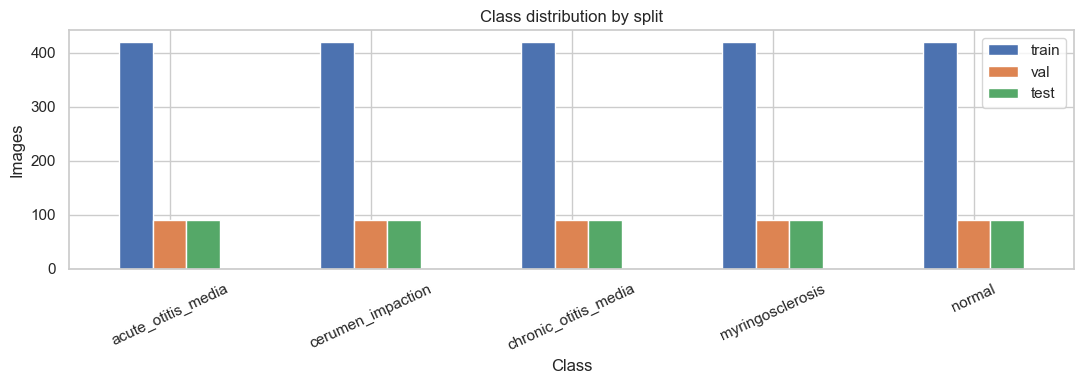

In [4]:
split_paths = {split: splits_dir / f'{split}.csv' for split in ['train', 'val', 'test']}
split_dfs = {split: pd.read_csv(path) for split, path in split_paths.items()}

split_sizes = pd.DataFrame(
    [{'split': split, 'rows': len(df)} for split, df in split_dfs.items()]
)
display(split_sizes)

class_dist = pd.concat(
    [split_dfs[split][label_col].value_counts().rename(split) for split in ['train', 'val', 'test']],
    axis=1,
).reindex(class_names).fillna(0).astype(int)
class_dist['total'] = class_dist.sum(axis=1)
display(class_dist)

ax = class_dist[['train', 'val', 'test']].plot(kind='bar', figsize=(11, 4), rot=25)
ax.set_title('Class distribution by split')
ax.set_xlabel('Class')
ax.set_ylabel('Images')
plt.tight_layout()

## 4. Xem sample anh

Lay 2 anh moi class tu train split de nhin lai input sau processing.

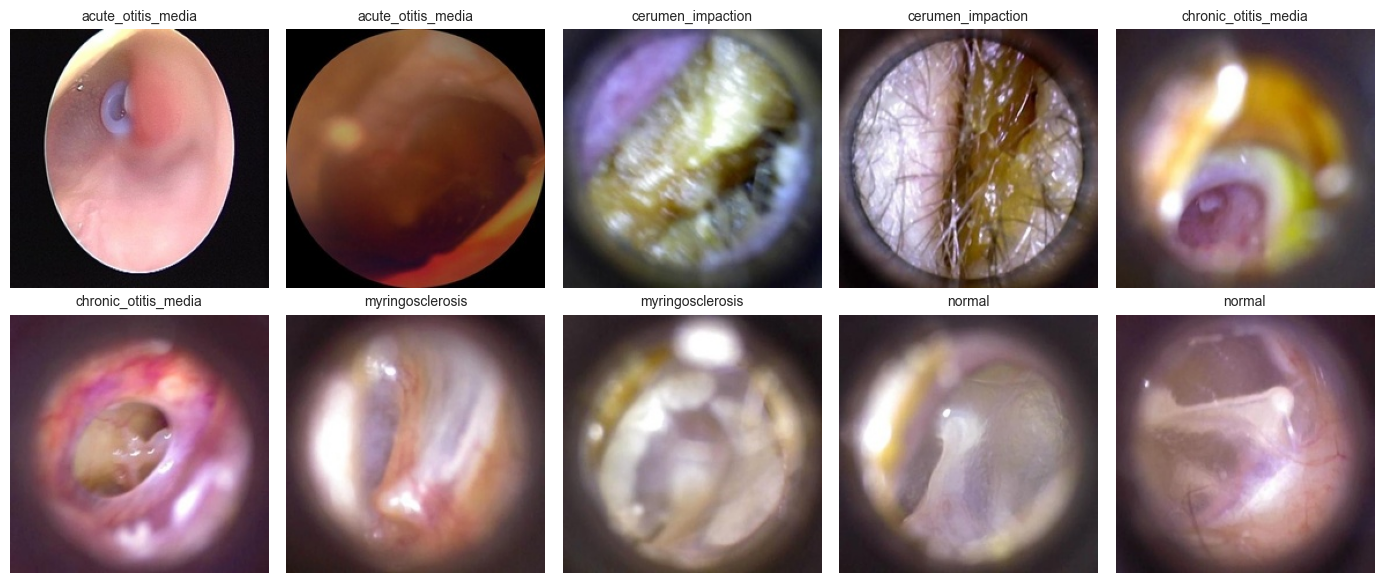

In [5]:
def resolve_image_path(image_path: str | Path) -> Path:
    path = Path(str(image_path))
    return path if path.is_absolute() else image_root / path


sample_parts = []
train_df = split_dfs['train']
for label in class_names:
    subset = train_df[train_df[label_col] == label]
    if len(subset) > 0:
        sample_parts.append(subset.sample(n=min(2, len(subset)), random_state=42))

sample_df = pd.concat(sample_parts).reset_index(drop=True)
ncols = 5
nrows = int(np.ceil(len(sample_df) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image_path = resolve_image_path(row[image_col])
    image = Image.open(image_path).convert('RGB')
    ax.imshow(image)
    ax.set_title(row[label_col], fontsize=10)
    ax.axis('off')

for ax in axes[len(sample_df):]:
    ax.axis('off')

plt.tight_layout()

## 5. Training history

Day la phan quan trong de xem ca qua trinh train cua ResNet50 theo tung epoch.

In [6]:
history = json.loads(HISTORY_PATH.read_text(encoding='utf-8'))
history_rows = []
for record in history:
    train = record.get('train', {})
    val = record.get('val', {})
    history_rows.append(
        {
            'epoch': record['epoch'],
            'train_loss': train.get('loss'),
            'train_accuracy': train.get('accuracy'),
            'val_loss': val.get('loss'),
            'val_accuracy': val.get('accuracy'),
            'val_macro_f1': val.get('macro_f1'),
            'val_balanced_accuracy': val.get('balanced_accuracy'),
            'lr': record.get('lr'),
        }
    )

history_df = pd.DataFrame(history_rows)
best_row = history_df.loc[history_df['val_macro_f1'].idxmax()]
last_row = history_df.iloc[-1]

display(history_df)
display(
    pd.DataFrame([best_row, last_row], index=['best_epoch_by_val_macro_f1', 'last_epoch'])[
        ['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1', 'lr']
    ]
)

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy,lr
0,1,1.079738,0.665714,0.358169,0.880000,0.872099,0.880000,0.000299
1,2,0.184866,0.951429,0.064254,0.973333,0.973247,0.973333,0.000297
2,3,0.058045,0.985714,0.035863,0.991111,0.991086,0.991111,0.000293
3,4,0.031572,0.992381,0.005808,0.997778,0.997778,0.997778,0.000287
4,5,0.017716,0.996667,0.005048,1.000000,1.000000,1.000000,0.000280
5,6,0.015518,0.996667,0.003691,1.000000,1.000000,1.000000,0.000271
6,7,0.014571,0.996190,0.004660,1.000000,1.000000,1.000000,0.000261
7,8,0.018379,0.992381,0.012229,0.993333,0.993321,0.993333,0.000250
8,9,0.007747,0.998571,0.005672,0.997778,0.997778,0.997778,0.000238
9,10,0.009732,0.998095,0.004670,0.997778,0.997778,0.997778,0.000225


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,lr
best_epoch_by_val_macro_f1,5.0,0.017716,0.996667,0.005048,1.000000,1.000000,0.000280
last_epoch,13.0,0.005441,0.998571,0.010252,0.997778,0.997778,0.000181


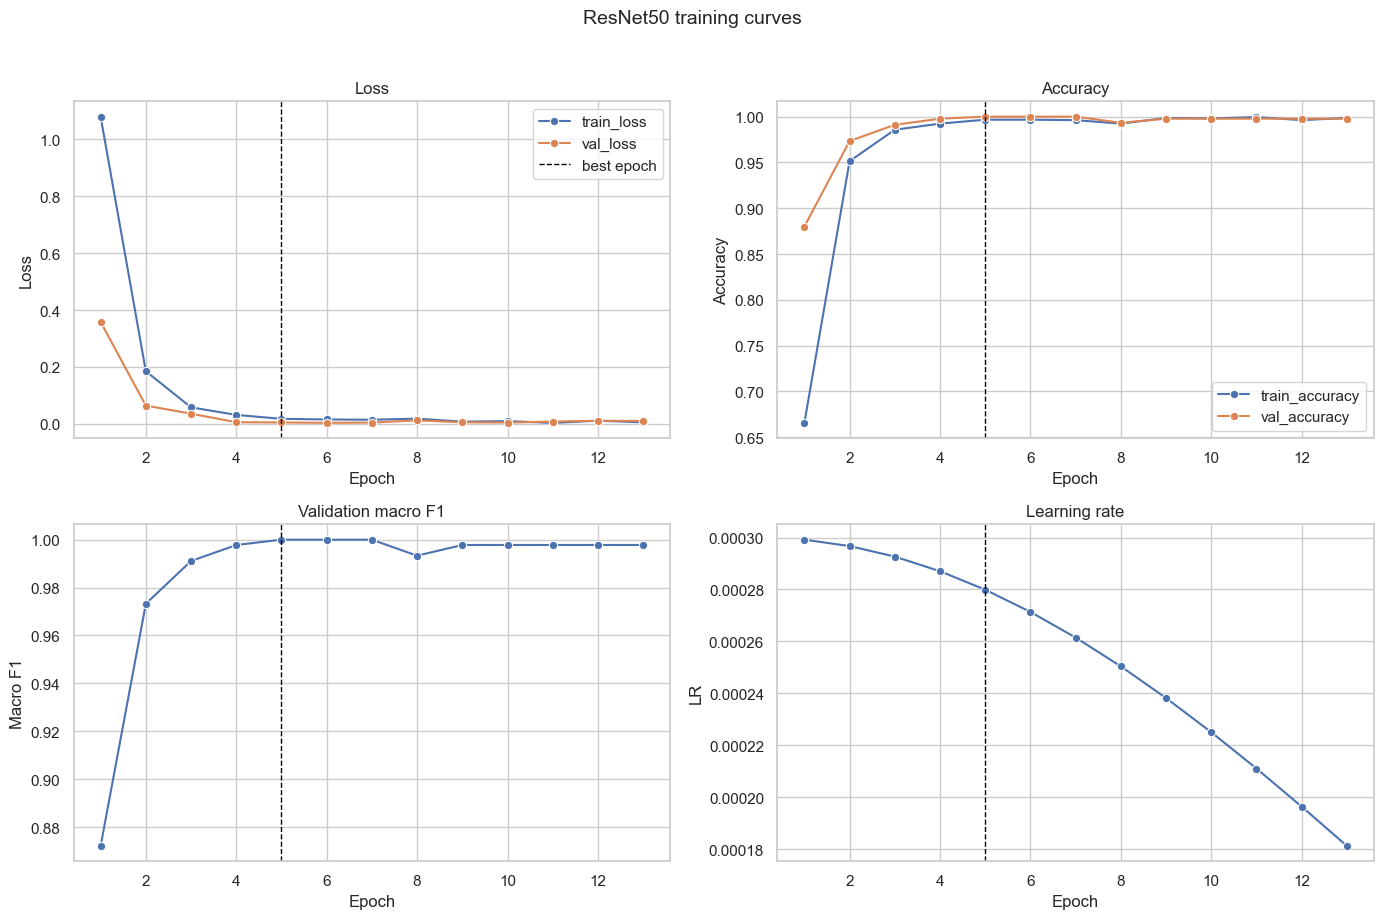

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.reshape(-1)

sns.lineplot(data=history_df, x='epoch', y='train_loss', marker='o', label='train_loss', ax=axes[0])
sns.lineplot(data=history_df, x='epoch', y='val_loss', marker='o', label='val_loss', ax=axes[0])
axes[0].axvline(best_row['epoch'], color='black', linestyle='--', linewidth=1, label='best epoch')
axes[0].set_title('Loss')
axes[0].set_ylabel('Loss')
axes[0].legend()

sns.lineplot(data=history_df, x='epoch', y='train_accuracy', marker='o', label='train_accuracy', ax=axes[1])
sns.lineplot(data=history_df, x='epoch', y='val_accuracy', marker='o', label='val_accuracy', ax=axes[1])
axes[1].axvline(best_row['epoch'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

sns.lineplot(data=history_df, x='epoch', y='val_macro_f1', marker='o', ax=axes[2])
axes[2].axvline(best_row['epoch'], color='black', linestyle='--', linewidth=1)
axes[2].set_title('Validation macro F1')
axes[2].set_ylabel('Macro F1')

sns.lineplot(data=history_df, x='epoch', y='lr', marker='o', ax=axes[3])
axes[3].axvline(best_row['epoch'], color='black', linestyle='--', linewidth=1)
axes[3].set_title('Learning rate')
axes[3].set_ylabel('LR')

for ax in axes:
    ax.set_xlabel('Epoch')

plt.suptitle('ResNet50 training curves', y=1.02, fontsize=14)
plt.tight_layout()

## 6. Test metrics va confusion matrix

Doc truc tiep tu `test_metrics.json`, dung de bao cao ket qua sau train.

,accuracy,macro_f1,weighted_f1,balanced_accuracy,roc_auc_ovr_macro,loss
0,1.0,1.0,1.0,1.0,1.0,0.004596


,precision,recall,f1-score,support
acute_otitis_media,1.0,1.0,1.0,90.0
cerumen_impaction,1.0,1.0,1.0,90.0
chronic_otitis_media,1.0,1.0,1.0,90.0
myringosclerosis,1.0,1.0,1.0,90.0
normal,1.0,1.0,1.0,90.0
macro avg,1.0,1.0,1.0,450.0
weighted avg,1.0,1.0,1.0,450.0


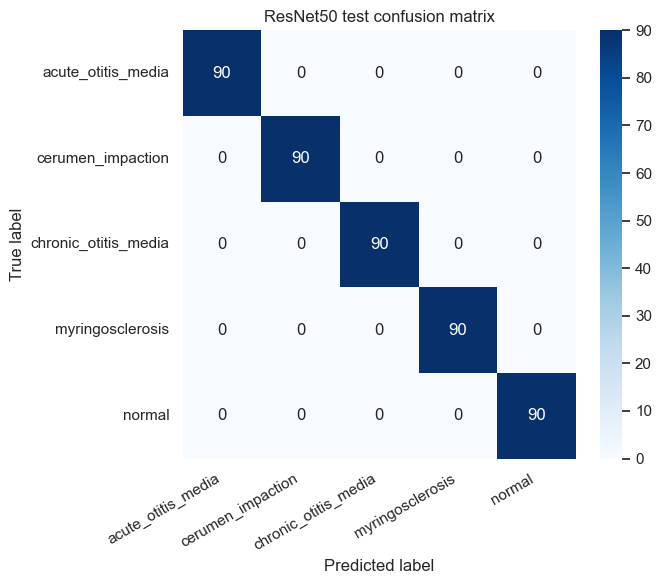

In [8]:
test_metrics = json.loads(TEST_METRICS_PATH.read_text(encoding='utf-8'))
metric_summary = pd.DataFrame(
    [
        {
            'accuracy': test_metrics.get('accuracy'),
            'macro_f1': test_metrics.get('macro_f1'),
            'weighted_f1': test_metrics.get('weighted_f1'),
            'balanced_accuracy': test_metrics.get('balanced_accuracy'),
            'roc_auc_ovr_macro': test_metrics.get('roc_auc_ovr_macro'),
            'loss': test_metrics.get('loss'),
        }
    ]
)
display(metric_summary)

report_df = pd.DataFrame(test_metrics['classification_report']).T
display(report_df.loc[class_names + ['macro avg', 'weighted avg'], ['precision', 'recall', 'f1-score', 'support']])

cm = np.array(test_metrics['confusion_matrix'])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('ResNet50 test confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

## 7. Load best checkpoint

Cell nay load `best.pt` va khoi tao dung architecture ResNet50 theo config trong checkpoint.

In [9]:
from ear_classifier.models.classifier import build_model

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
checkpoint_model_cfg = checkpoint.get('model_config', model_cfg)
checkpoint_classes = checkpoint.get('class_names', class_names)

model = build_model(
    model_name=checkpoint_model_cfg.get('name', 'resnet50'),
    num_classes=len(checkpoint_classes),
    pretrained=False,
    dropout=float(checkpoint_model_cfg.get('dropout', 0.0)),
    library=checkpoint_model_cfg.get('library', 'auto'),
).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Loaded checkpoint:', CHECKPOINT_PATH)
print('Checkpoint epoch:', checkpoint.get('epoch'))
print('Checkpoint model config:', checkpoint_model_cfg)
print('Checkpoint classes:', checkpoint_classes)

Loaded checkpoint: C:\Users\ADMIN\Desktop\New folder\models\checkpoints\baseline_resnet50\best.pt
Checkpoint epoch: 5
Checkpoint model config: {'name': 'resnet50', 'library': 'timm', 'pretrained': True, 'dropout': 0.2}
Checkpoint classes: ['acute_otitis_media', 'cerumen_impaction', 'chronic_otitis_media', 'myringosclerosis', 'normal']


## 8. Re-evaluate checkpoint trong notebook

Chay lai evaluation tren test split de dam bao checkpoint va data dang khop. Trong notebook de `num_workers=0` cho on dinh tren Windows/Jupyter.

In [10]:
from ear_classifier.data.dataset import OtoscopyImageDataset
from ear_classifier.data.transforms import build_transforms
from ear_classifier.training.trainer import evaluate_loader

test_ds = OtoscopyImageDataset(
    labels=splits_dir / 'test.csv',
    image_root=image_root,
    class_names=checkpoint_classes,
    image_col=image_col,
    label_col=label_col,
    transform=build_transforms(data_cfg, train=False),
)

test_loader = DataLoader(
    test_ds,
    batch_size=int(train_cfg.get('batch_size', 32)),
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == 'cuda',
)

criterion = nn.CrossEntropyLoss()
notebook_metrics = evaluate_loader(model, test_loader, criterion, DEVICE, checkpoint_classes)
display(
    pd.DataFrame(
        [
            {
                'accuracy': notebook_metrics.get('accuracy'),
                'macro_f1': notebook_metrics.get('macro_f1'),
                'balanced_accuracy': notebook_metrics.get('balanced_accuracy'),
                'loss': notebook_metrics.get('loss'),
            }
        ]
    )
)

,accuracy,macro_f1,balanced_accuracy,loss
0,1.0,1.0,1.0,0.004596


## 9. Error analysis

Neu model co du doan sai, cell nay se liet ke cac sample sai kem confidence. Voi run hien tai ResNet50 dang dat test accuracy 1.0 nen co the khong co error.

In [11]:
@torch.inference_mode()
def collect_predictions(model: torch.nn.Module, loader: DataLoader, device: torch.device, classes: list[str]) -> pd.DataFrame:
    model.eval()
    y_true = []
    probs_all = []

    for images, targets, _meta in tqdm(loader, desc='predict'):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        y_true.extend(targets.cpu().tolist())
        probs_all.extend(probs.cpu().tolist())

    probs_array = np.asarray(probs_all)
    pred_idx = probs_array.argmax(axis=1)
    pred_df = test_ds.df.copy().reset_index(drop=True)
    pred_df['true_label'] = [classes[idx] for idx in y_true]
    pred_df['pred_label'] = [classes[idx] for idx in pred_idx]
    pred_df['confidence'] = probs_array.max(axis=1)
    pred_df['correct'] = pred_df['true_label'] == pred_df['pred_label']
    for idx, class_name in enumerate(classes):
        pred_df[f'prob_{class_name}'] = probs_array[:, idx]
    return pred_df


pred_df = collect_predictions(model, test_loader, DEVICE, checkpoint_classes)
error_df = pred_df[~pred_df['correct']].sort_values('confidence', ascending=False)

print(f'Test samples: {len(pred_df)}')
print(f'Errors: {len(error_df)}')
if len(error_df) > 0:
    display(error_df[[image_col, 'true_label', 'pred_label', 'confidence']].head(20))
else:
    print('No misclassified test samples for this checkpoint.')

predict: 100%|██████████| 15/15 [00:01<00:00,  9.83it/s]

Test samples: 450
Errors: 0
No misclassified test samples for this checkpoint.


## 10. Predict thu mot anh

Doi `sample_index` de xem anh khac trong test split.

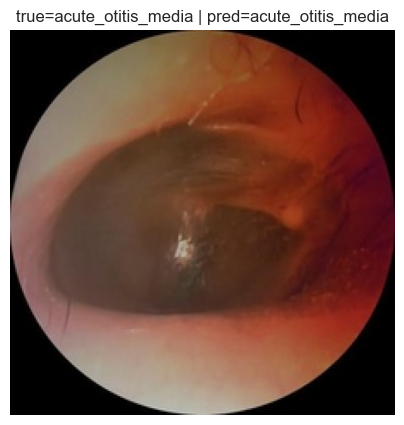

,class,probability
0,acute_otitis_media,0.998599
1,cerumen_impaction,0.000573
3,myringosclerosis,0.000338
4,normal,0.000262
2,chronic_otitis_media,0.000227


In [12]:
sample_index = 0
row = pred_df.iloc[sample_index]
sample_image_path = resolve_image_path(row[image_col])
sample_image = Image.open(sample_image_path).convert('RGB')
eval_transform = build_transforms(data_cfg, train=False)

with torch.inference_mode():
    image_tensor = eval_transform(sample_image).unsqueeze(0).to(DEVICE)
    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy().reshape(-1)

prob_table = pd.DataFrame({'class': checkpoint_classes, 'probability': probs}).sort_values(
    'probability', ascending=False
)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.title(f"true={row['true_label']} | pred={prob_table.iloc[0]['class']}")
plt.axis('off')
plt.show()

display(prob_table)

## 11. Rerun training/evaluation khi can

Neu muon train lai ResNet50 tu notebook, bo comment cac command ben duoi. Train co the mat nhieu thoi gian tuy CPU/CUDA.

In [13]:
# %cd $PROJECT_ROOT
# !python scripts/train.py --config configs/train_resnet50.yaml
# !python scripts/evaluate.py --config configs/train_resnet50.yaml --checkpoint models/checkpoints/baseline_resnet50/best.pt --split test
# !python scripts/summarize_run.py --run-name baseline_resnet50

## Notes khi viet report

- ResNet50 hien tai dat test accuracy va macro F1 bang 1.0 tren split nay.
- Dataset kha clean va moi class can bang, nen can ghi ro day la image-level validation.
- Split da co group theo `raw_sha256` de tranh duplicate raw image cross-split, nhung dataset khong co real patient ID.